In [16]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, kruskal

df_profile_real = pd.read_csv("clustered_startups_real_values.csv")

In [17]:
real_features = [
    'funding_total_usd',
    'funding_rounds',
    'early_stage_funding',
    'venture',
    'debt_financing',
    'private_equity',
    'stage_level'
]

real_features = [col for col in real_features if col in df_profile_real.columns]

cluster_summary_real = (
    df_profile_real
    .groupby('Cluster')[real_features]
    .median()
    .round(0)
)

cluster_summary_real

,funding_total_usd,funding_rounds,early_stage_funding,venture,debt_financing,private_equity,stage_level
Cluster,,,,,,,
0,1000000.0,1.0,28000.0,35000.0,0.0,0.0,0.0
1,5550000.0,3.0,0.0,1450000.0,1315802.0,0.0,0.0
2,36850000.0,2.0,0.0,0.0,0.0,18400000.0,0.0
3,16000000.0,3.0,0.0,15000000.0,0.0,0.0,2.0


In [18]:
cluster_sizes = (
    df_profile_real['Cluster']
    .value_counts()
    .sort_index()
    .rename('Count')
    .to_frame()
)

cluster_sizes['Percentage'] = (
    cluster_sizes['Count'] / cluster_sizes['Count'].sum() * 100
).round(2)

cluster_sizes

,Count,Percentage
Cluster,,
0,24835,67.25
1,3819,10.34
2,1305,3.53
3,6972,18.88


In [19]:
real_features = [
    'funding_total_usd',
    'funding_rounds',
    'early_stage_funding',
    'venture',
    'debt_financing',
    'private_equity',
    'stage_level'
]

real_features = [col for col in real_features if col in df_profile_real.columns]

cluster_median_profile = (
    df_profile_real
    .groupby('Cluster')[real_features]
    .median()
    .round(0)
)

cluster_mean_profile = (
    df_profile_real
    .groupby('Cluster')[real_features]
    .mean()
    .round(0)
)

cluster_median_profile

,funding_total_usd,funding_rounds,early_stage_funding,venture,debt_financing,private_equity,stage_level
Cluster,,,,,,,
0,1000000.0,1.0,28000.0,35000.0,0.0,0.0,0.0
1,5550000.0,3.0,0.0,1450000.0,1315802.0,0.0,0.0
2,36850000.0,2.0,0.0,0.0,0.0,18400000.0,0.0
3,16000000.0,3.0,0.0,15000000.0,0.0,0.0,2.0


In [20]:
def format_usd(x):
    if pd.isna(x):
        return ""
    if abs(x) >= 1_000_000_000:
        return f"${x/1_000_000_000:.2f}B"
    elif abs(x) >= 1_000_000:
        return f"${x/1_000_000:.2f}M"
    elif abs(x) >= 1_000:
        return f"${x/1_000:.1f}K"
    else:
        return f"${x:,.0f}"

money_cols = [
    'funding_total_usd',
    'early_stage_funding',
    'venture',
    'debt_financing',
    'private_equity'
]

cluster_summary_real = cluster_sizes.join(cluster_median_profile)

format_dict = {'Percentage': '{:.2f}%'}

for col in money_cols:
    if col in cluster_summary_real.columns:
        format_dict[col] = format_usd

for col in ['funding_rounds', 'stage_level']:
    if col in cluster_summary_real.columns:
        format_dict[col] = '{:.0f}'

display(
    cluster_summary_real
    .style
    .format(format_dict)
    .set_caption("Cluster Summary with Real Median Values")
)

,Count,Percentage,funding_total_usd,funding_rounds,early_stage_funding,venture,debt_financing,private_equity,stage_level
Cluster,,,,,,,,,
0,24835,67.25%,$1.00M,1,$28.0K,$35.0K,$0,$0,0
1,3819,10.34%,$5.55M,3,$0,$1.45M,$1.32M,$0,0
2,1305,3.53%,$36.85M,2,$0,$0,$0,$18.40M,0
3,6972,18.88%,$16.00M,3,$0,$15.00M,$0,$0,2


In [21]:
df_profile_real['venture_share'] = np.where(
    df_profile_real['funding_total_usd'] > 0,
    df_profile_real['venture'] / df_profile_real['funding_total_usd'],
    0
)

df_profile_real['debt_share'] = np.where(
    df_profile_real['funding_total_usd'] > 0,
    df_profile_real['debt_financing'] / df_profile_real['funding_total_usd'],
    0
)

df_profile_real['private_equity_share'] = np.where(
    df_profile_real['funding_total_usd'] > 0,
    df_profile_real['private_equity'] / df_profile_real['funding_total_usd'],
    0
)

df_profile_real['early_stage_share'] = np.where(
    df_profile_real['funding_total_usd'] > 0,
    df_profile_real['early_stage_funding'] / df_profile_real['funding_total_usd'],
    0
)

share_cols = [
    'early_stage_share',
    'venture_share',
    'debt_share',
    'private_equity_share'
]

cluster_funding_share = (
    df_profile_real
    .groupby('Cluster')[share_cols]
    .median()
    .round(3)
)

display(
    cluster_funding_share
    .style
    .format("{:.1%}")
    .set_caption("Median Funding Composition by Cluster")
)

,early_stage_share,venture_share,debt_share,private_equity_share
Cluster,,,,
0,50.0%,29.7%,0.0%,0.0%
1,0.0%,45.0%,38.0%,0.0%
2,0.0%,0.0%,0.0%,98.8%
3,0.0%,100.0%,0.0%,0.0%


In [22]:
status_by_cluster = pd.crosstab(
    df_profile_real['Cluster'],
    df_profile_real['status'],
    normalize='index'
) * 100

status_by_cluster = status_by_cluster.round(2)

display(
    status_by_cluster
    .style
    .format("{:.2f}%")
    .set_caption("Company Status Distribution by Cluster")
)

status,acquired,closed,operating
Cluster,,,
0,5.86%,6.53%,87.61%
1,9.30%,4.56%,86.14%
2,8.09%,1.67%,90.25%
3,18.03%,4.47%,77.50%


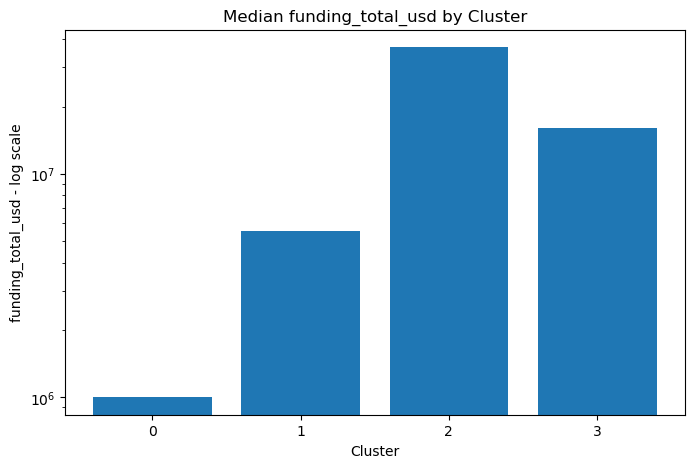

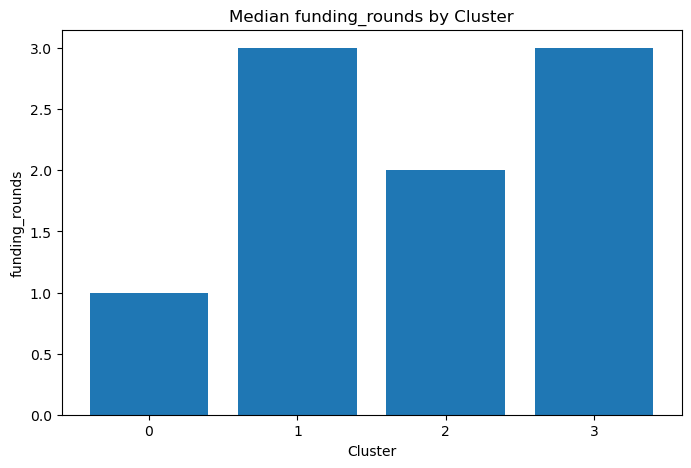

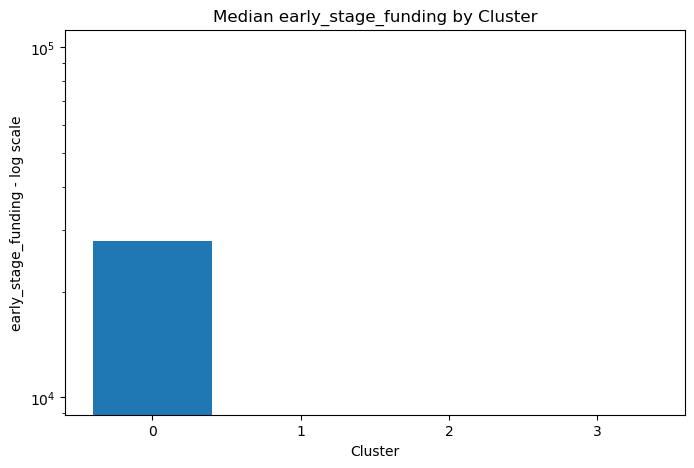

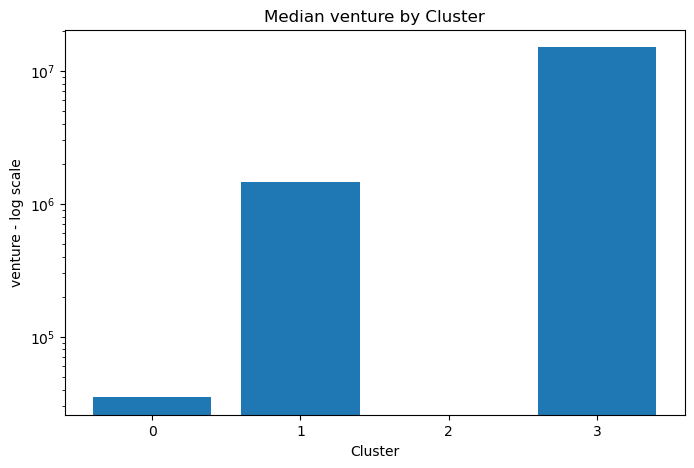

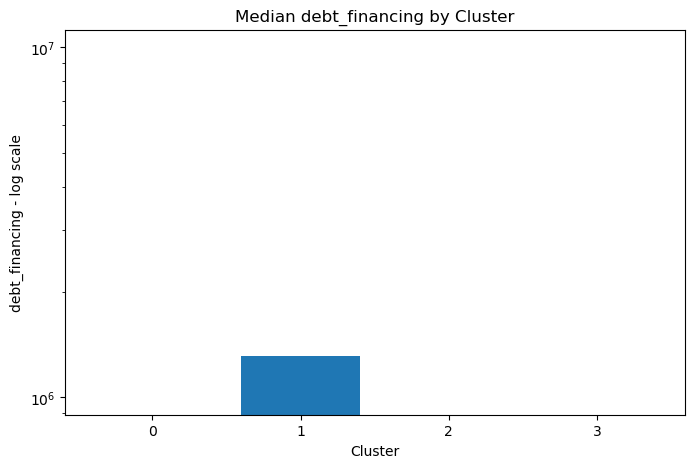

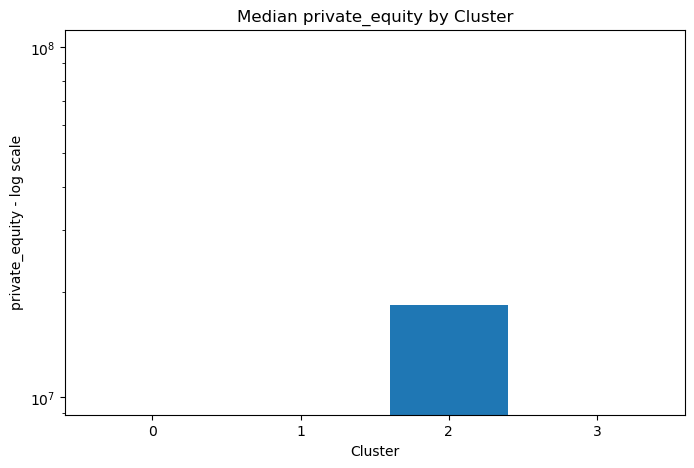

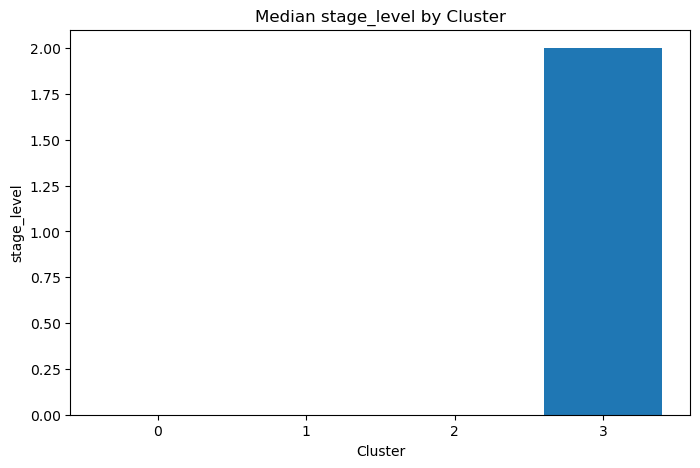

In [23]:
for col in real_features:
    medians = (
        df_profile_real
        .groupby('Cluster')[col]
        .median()
        .sort_index()
    )
    
    plt.figure(figsize=(8, 5))
    plt.bar(medians.index.astype(str), medians.values)
    plt.title(f"Median {col} by Cluster")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    
    if col in money_cols:
        plt.yscale("log")
        plt.ylabel(f"{col} - log scale")
    
    plt.show()

In [30]:
top_markets_by_cluster = (
    df_profile_real
    .groupby('Cluster')['market']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

top_markets_by_cluster = (
    top_markets_by_cluster
    .sort_values(['Cluster', 'Percentage'], ascending=[True, False])
)

top_markets_by_cluster.groupby('Cluster').head(10)

,Cluster,market,Percentage
0,0,Software,10.517415
1,0,Biotechnology,7.276022
2,0,Mobile,4.690960
3,0,E-Commerce,4.159452
4,0,Curated Web,4.107107
5,0,Games,2.685726
6,0,Enterprise Software,2.613247
7,0,Hardware + Software,2.391786
8,0,Social Media,2.367626
9,0,Advertising,2.307228


C:\Users\pedro\AppData\Local\Temp\ipykernel_23564\3387398562.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sorted(df_profile_real['Cluster'].unique()), showfliers=False)


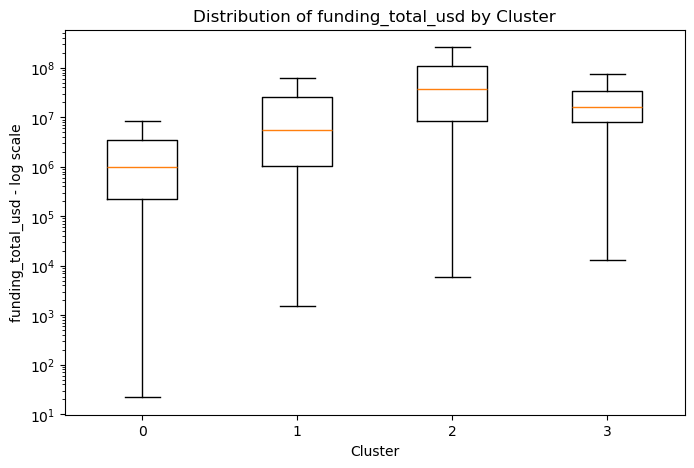

C:\Users\pedro\AppData\Local\Temp\ipykernel_23564\3387398562.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sorted(df_profile_real['Cluster'].unique()), showfliers=False)


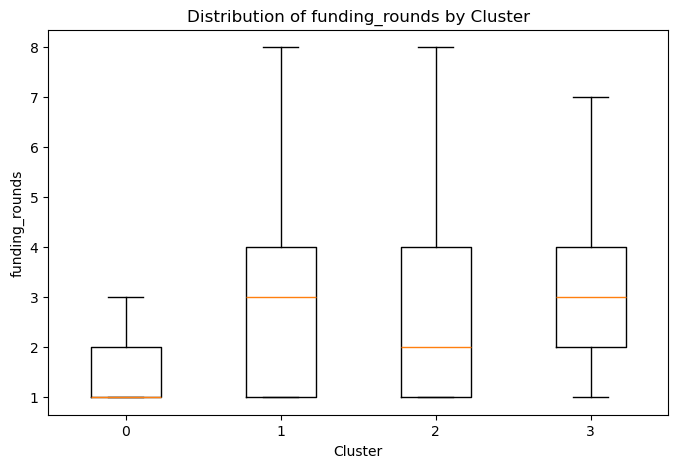

C:\Users\pedro\AppData\Local\Temp\ipykernel_23564\3387398562.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sorted(df_profile_real['Cluster'].unique()), showfliers=False)


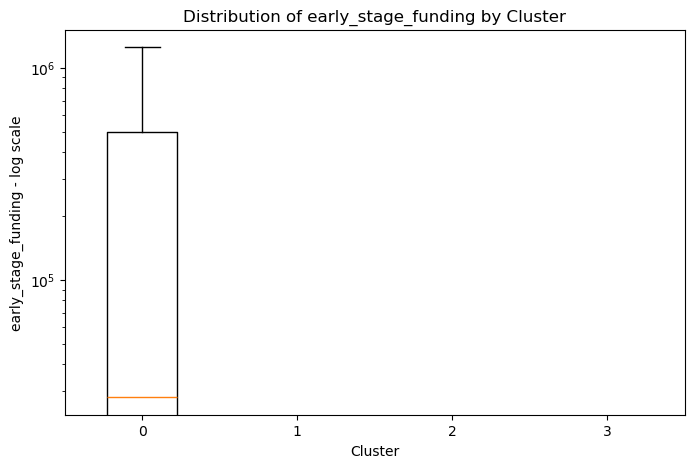

C:\Users\pedro\AppData\Local\Temp\ipykernel_23564\3387398562.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sorted(df_profile_real['Cluster'].unique()), showfliers=False)


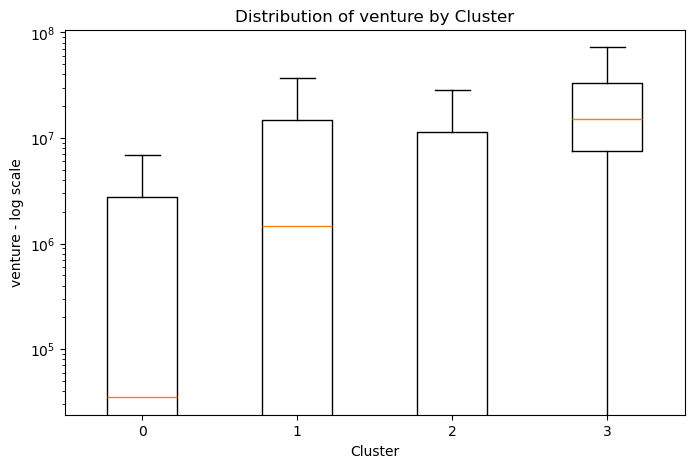

C:\Users\pedro\AppData\Local\Temp\ipykernel_23564\3387398562.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sorted(df_profile_real['Cluster'].unique()), showfliers=False)


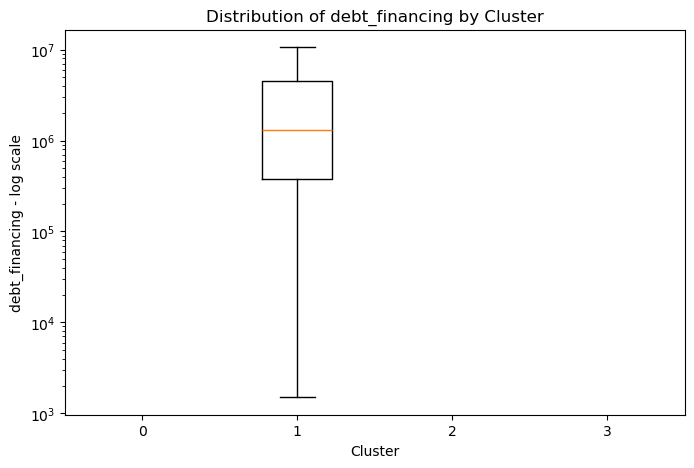

C:\Users\pedro\AppData\Local\Temp\ipykernel_23564\3387398562.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sorted(df_profile_real['Cluster'].unique()), showfliers=False)


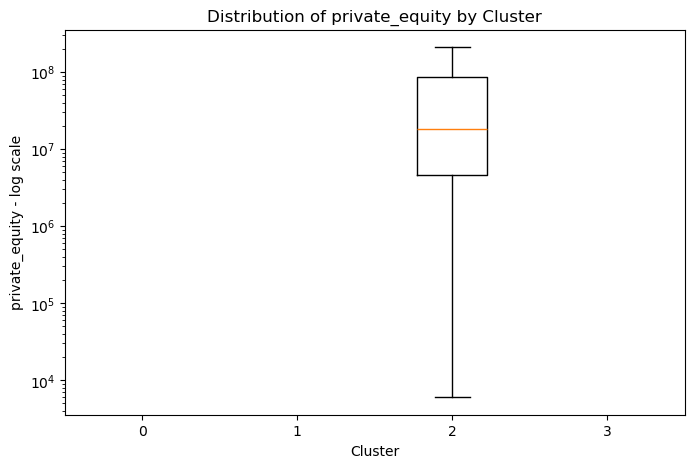

C:\Users\pedro\AppData\Local\Temp\ipykernel_23564\3387398562.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sorted(df_profile_real['Cluster'].unique()), showfliers=False)


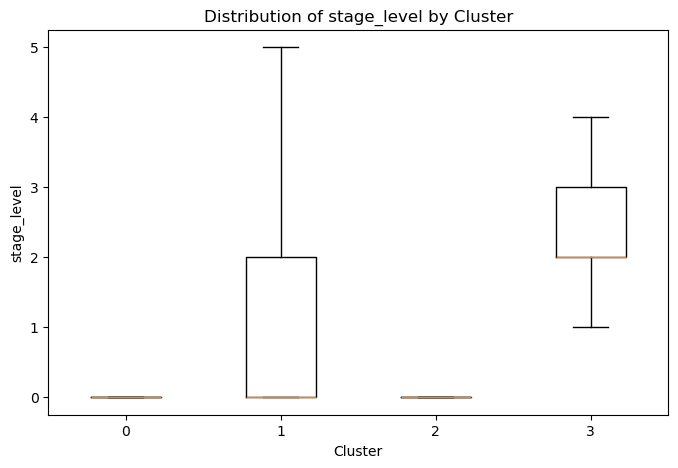

In [27]:
for col in real_features:
    data = [
        df_profile_real[df_profile_real['Cluster'] == cluster][col].dropna()
        for cluster in sorted(df_profile_real['Cluster'].unique())
    ]
    
    plt.figure(figsize=(8, 5))
    plt.boxplot(data, labels=sorted(df_profile_real['Cluster'].unique()), showfliers=False)
    plt.title(f"Distribution of {col} by Cluster")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    
    if col in money_cols:
        plt.yscale("log")
        plt.ylabel(f"{col} - log scale")
    
    plt.show()

In [25]:
cluster_names = {
    0: "Early-stage / low funding",
    1: "Debt-financed startups",
    2: "Private equity / capital intensive",
    3: "Venture-backed growth"
}

df_profile_real['Cluster_Name'] = df_profile_real['Cluster'].map(cluster_names)

df_profile_real[['Cluster', 'Cluster_Name']].drop_duplicates().sort_values('Cluster')

,Cluster,Cluster_Name
0,0,Early-stage / low funding
9,1,Debt-financed startups
46,2,Private equity / capital intensive
4,3,Venture-backed growth


In [26]:
final_cluster_report = cluster_summary_real.copy()

# Add status percentages if available
if 'status' in df_profile_real.columns:
    status_percentages = pd.crosstab(
        df_profile_real['Cluster'],
        df_profile_real['status'],
        normalize='index'
    ) * 100
    
    status_percentages = status_percentages.round(2)
    final_cluster_report = final_cluster_report.join(status_percentages)

# Add cluster names
final_cluster_report.insert(
    0,
    'Cluster_Name',
    final_cluster_report.index.map(cluster_names)
)

final_cluster_report

,Cluster_Name,Count,Percentage,funding_total_usd,funding_rounds,early_stage_funding,venture,debt_financing,private_equity,stage_level,acquired,closed,operating
Cluster,,,,,,,,,,,,,
0,Early-stage / low funding,24835,67.25,1000000.0,1.0,28000.0,35000.0,0.0,0.0,0.0,5.86,6.53,87.61
1,Debt-financed startups,3819,10.34,5550000.0,3.0,0.0,1450000.0,1315802.0,0.0,0.0,9.30,4.56,86.14
2,Private equity / capital intensive,1305,3.53,36850000.0,2.0,0.0,0.0,0.0,18400000.0,0.0,8.09,1.67,90.25
3,Venture-backed growth,6972,18.88,16000000.0,3.0,0.0,15000000.0,0.0,0.0,2.0,18.03,4.47,77.50
